<div class="alert alert-block alert-info">
    <h1>Análisis de Series Temporales</h1>
    <h3>Clase 6</h3>
    <h3>Ejercicio 1</h3>
        <p>Docente: Rodrigo Del Rosso<p>
        <p><p>Asistente: Sebastián Calcagno<p> <p>
</div>

Modelos Ensambles   

Los modelos de Gradient Boosting han mostrado su eficacia. La adaptacion de estos modelos al dominio de series temporales es esencial, ya que las características únicas de este tipo de datos, como la dependencia temporal y la estacionalidad, requieren un enfoque especializado.

Aca vamos a trabajar con modelos de ensamble basados en árboles (XGBoost y LightGBM) aplicados al pronostico de una serie temporal real de consumo energetico.

Gradient Boost funciona muy bien si se construyen bien los features

Comentarios mios:
- El feature engineering es tan importante como el modelo.
- El uso de early stopping y learning rate bajo ayuda a generalizar mejor
- LightGBM y XGBoost son alternativas muy fuertes

Queremos predecir el consumo futuro.  

Documentación: https://xgboost.readthedocs.io/en/stable/python/python_intro.html

Carga de Librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from xgboost import plot_importance, plot_tree
color_pal = sns.color_palette()
plt.style.use('tableau-colorblind10')

# Carga y Procesamiento inicial del dataset

Es un dataset de uso en Kaggle - que a su vez proviene del sitio web de PJM (https://www.pjm.com/)

In [ ]:
URL='https://raw.githubusercontent.com/sebcalcagno/AnalisisSeriesTemporales/main/consumo_2.csv'
df = pd.read_csv(URL)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  object 
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.2+ MB


In [ ]:
df['Datetime'].dtype

dtype('O')

In [ ]:
df['Datetime'] = pd.to_datetime(df['Datetime'], format='%Y-%m-%d %H:%M:%S')


In [ ]:
df = df.set_index('Datetime')
df.sort_index(inplace=True)
print(df.shape)
df.head()

(145366, 1)


,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


In [ ]:
pd.to_datetime(df.index)

DatetimeIndex(['2002-01-01 01:00:00', '2002-01-01 02:00:00',
               '2002-01-01 03:00:00', '2002-01-01 04:00:00',
               '2002-01-01 05:00:00', '2002-01-01 06:00:00',
               '2002-01-01 07:00:00', '2002-01-01 08:00:00',
               '2002-01-01 09:00:00', '2002-01-01 10:00:00',
               ...
               '2018-08-02 15:00:00', '2018-08-02 16:00:00',
               '2018-08-02 17:00:00', '2018-08-02 18:00:00',
               '2018-08-02 19:00:00', '2018-08-02 20:00:00',
               '2018-08-02 21:00:00', '2018-08-02 22:00:00',
               '2018-08-02 23:00:00', '2018-08-03 00:00:00'],
              dtype='datetime64[ns]', name='Datetime', length=145366, freq=None)

In [ ]:
df.tail()

,PJME_MW
Datetime,
2018-08-02 20:00:00,44057.0
2018-08-02 21:00:00,43256.0
2018-08-02 22:00:00,41552.0
2018-08-02 23:00:00,38500.0
2018-08-03 00:00:00,35486.0


Los datos tienen una frecuencia de registro cada 1 hora

**Visualizamos la serie:**

In [ ]:
sns.color_palette()

[(0.0, 0.4196078431372549, 0.6431372549019608),
 (1.0, 0.5019607843137255, 0.054901960784313725),
 (0.6705882352941176, 0.6705882352941176, 0.6705882352941176),
 (0.34901960784313724, 0.34901960784313724, 0.34901960784313724),
 (0.37254901960784315, 0.6196078431372549, 0.8196078431372549),
 (0.7843137254901961, 0.3215686274509804, 0.0),
 (0.5372549019607843, 0.5372549019607843, 0.5372549019607843),
 (0.6352941176470588, 0.7843137254901961, 0.9254901960784314),
 (1.0, 0.7372549019607844, 0.4745098039215686),
 (0.8117647058823529, 0.8117647058823529, 0.8117647058823529)]

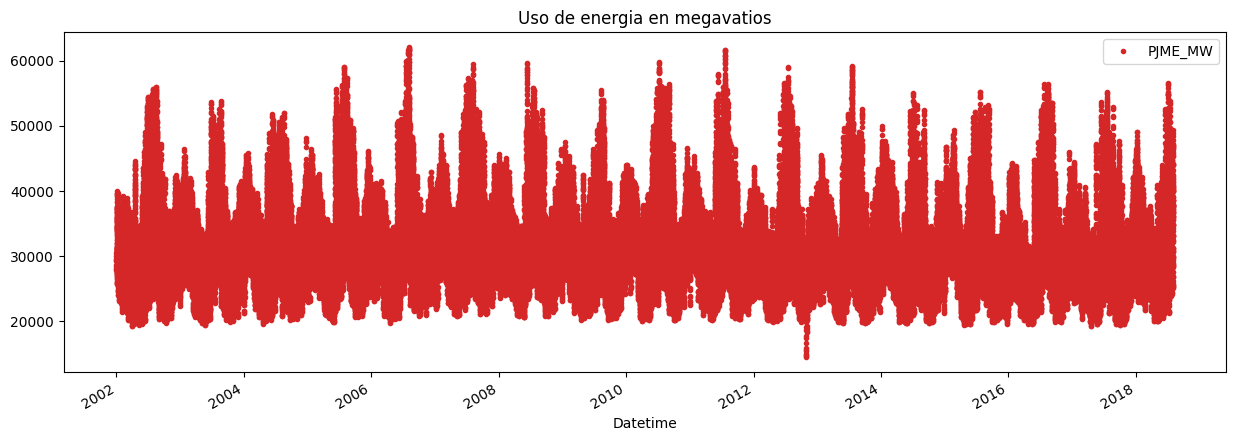

In [ ]:
df.plot(style='.',
        figsize=(15, 5),
        color=color_pal[3],
        title='Uso de energia en megavatios')
plt.show()

Que observamos en la gráfica?

Presencia de outliers ? <br/>
Valores faltante ?

Valores faltantes

In [ ]:
print('Cantidad de NaNs:')
for column in df:
    nans = df[column].isna().sum()
    print(f'\tColumna {column}: {nans}')

# XGBoost y LightGBM pueden entrenar con NaNs

Cantidad de NaNs:
	Columna PJME_MW: 0


Separamos train y test

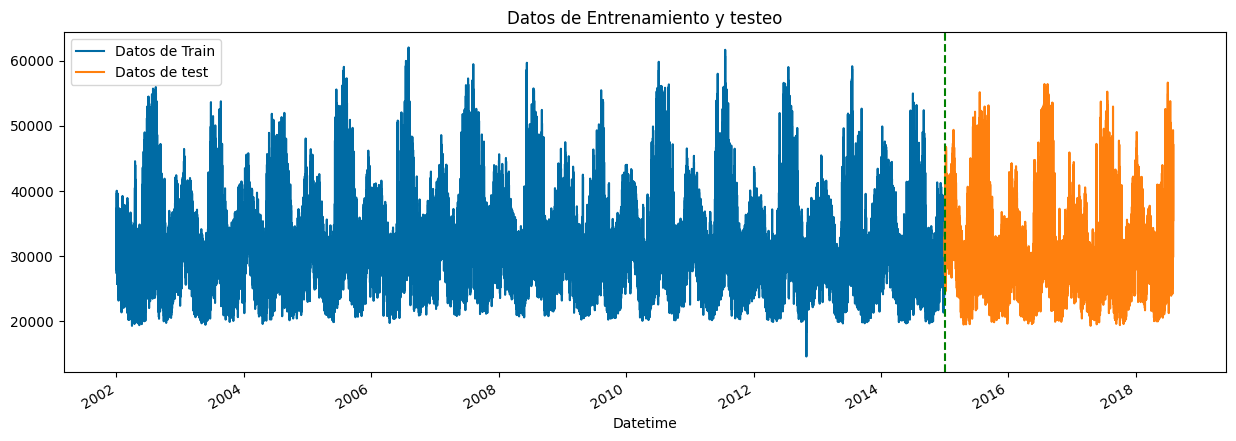

In [ ]:
train = df.loc[df.index < '01-01-2015']
test = df.loc[df.index >= '01-01-2015']

fig, ax = plt.subplots(figsize=(15, 5))
train.plot(ax=ax, label='Datos de Train', title='Datos de Entrenamiento y testeo')
test.plot(ax=ax, label='Datos de test')
ax.axvline('01-01-2015', color='green', ls='--')
ax.legend(['Datos de Train', 'Datos de test'])
plt.show()

**Feature Engineering**

https://pandas.pydata.org/docs/reference/api/pandas.DatetimeIndex.dayofweek.html

In [ ]:
def create_features(df):
    """
    Creamos features basadas en el índice tiempo.
    """
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

In [ ]:
df = create_features(df)
train = create_features(train)
test = create_features(test)

In [ ]:
FEATURES = ['hour', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear']
TARGET = 'PJME_MW'

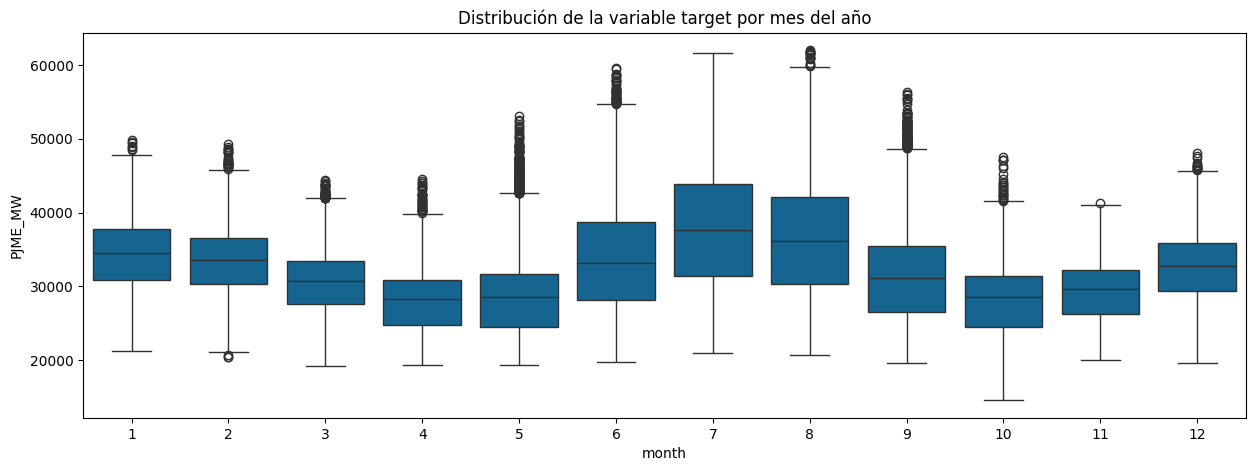

In [ ]:
fig, ax = plt.subplots(figsize=(15, 5))
sns.boxplot(data=df, x = 'month' , y = 'PJME_MW')
ax.set_title('Distribución de la variable target por mes del año')
plt.show()

Entrenamiento

n_estimators = cuantos arboles crea el modelo

early_stopping_rounds= si el modelo no mejora el entrenamiento para.

eval_set=[(X_train, y_train), (X_test, y_test)]: Asi evalua en el entrenamiento, asi nutre el early stoppig rounds.

In [ ]:
X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

# XGBoost (Extreme Gradient Boosting)

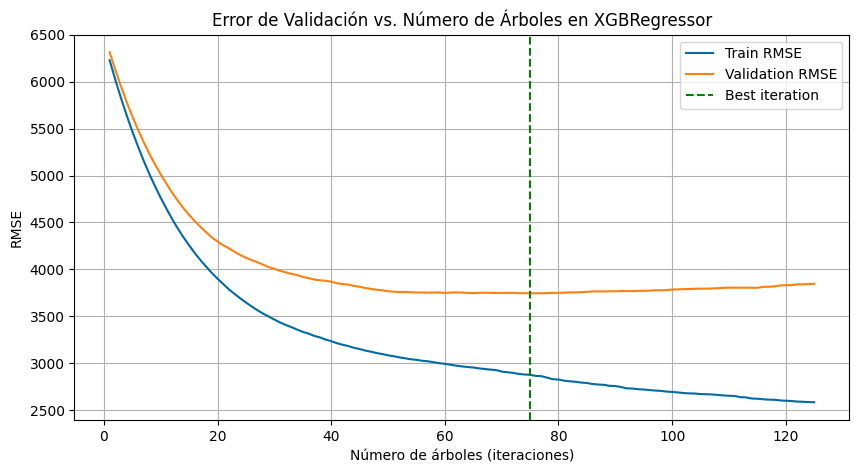

Mejor número de árboles (best_iteration): 75


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import xgboost as xgb


regXGB = xgb.XGBRegressor(
    n_estimators=1000,
    early_stopping_rounds=50,
    eval_metric="rmse",
    learning_rate=0.05,  # probar aca
    verbosity=0
)

regXGB.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)

results = regXGB.evals_result()

train_rmse = results['validation_0']['rmse']
test_rmse = results['validation_1']['rmse']
iterations = np.arange(len(train_rmse)) + 1

plt.figure(figsize=(10, 5))
plt.plot(iterations, train_rmse, label='Train RMSE')
plt.plot(iterations, test_rmse, label='Validation RMSE')
plt.axvline(regXGB.best_iteration + 1, color='green', linestyle='--', label='Best iteration')

plt.xlabel('Número de árboles (iteraciones)')
plt.ylabel('RMSE')
plt.title('Error de Validación vs. Número de Árboles en XGBRegressor')
plt.legend()
plt.grid(True)
plt.show()

print(f"Mejor número de árboles (best_iteration): {regXGB.best_iteration + 1}")

Al bajar el learning_rate el modelo aprende de forma más suave y necesita mas árboles mientras que al usar un learning_rate alto aprende rápido pero debemos tener cuidado con el overfitting. En forecasting suele ser recomendable bajar el learning_rate y permitir mas árboles con early_stopping para equilibrar eficiencia y generalizacion

Al bajar el learning rate de 0.3 a 0.05el modelo aprende de forma mas suave se necesitan mas arboles pero reduciendo el riesgo de overfitting temprano, logrando una mejor generalización en forecasting

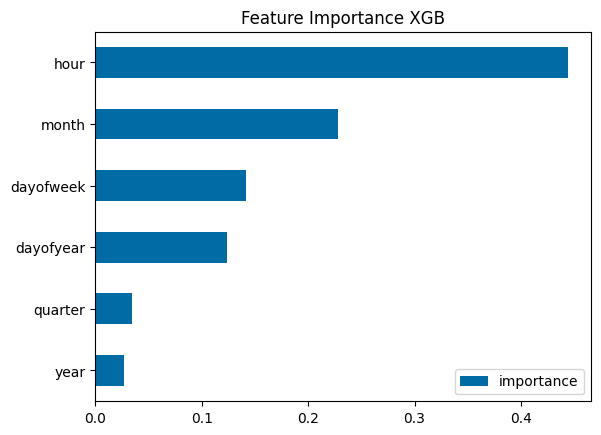

In [ ]:
fi = pd.DataFrame(data=regXGB.feature_importances_,
             index=regXGB.feature_names_in_,
             columns=['importance'])
fi.sort_values('importance').plot(kind='barh', title='Feature Importance XGB')
plt.show()

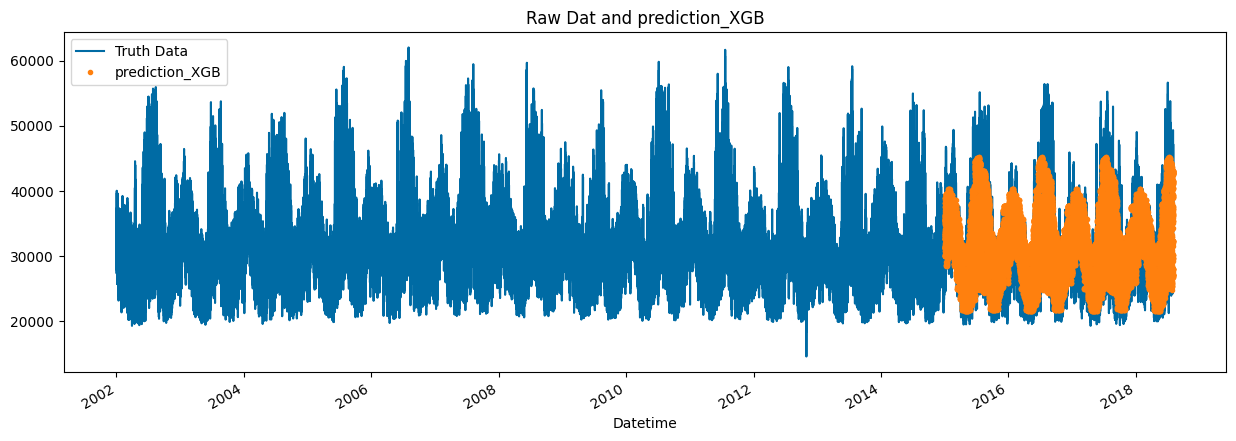

In [ ]:
test['prediction_XGB'] = regXGB.predict(X_test)
df = df.merge(test[['prediction_XGB']], how='left', left_index=True, right_index=True)
ax = df[['PJME_MW']].plot(figsize=(15, 5))
df['prediction_XGB'].plot(ax=ax, style='.')
plt.legend(['Truth Data', 'prediction_XGB'])
ax.set_title('Raw Dat and prediction_XGB')
plt.show()

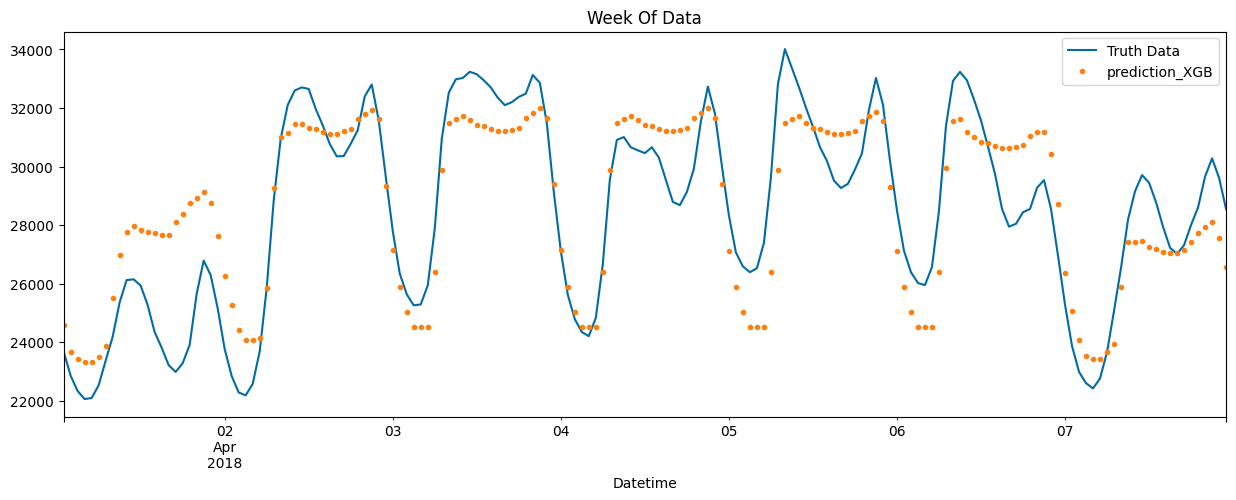

In [ ]:
ax = df.loc[(df.index > '04-01-2018') & (df.index < '04-08-2018')]['PJME_MW'] \
    .plot(figsize=(15, 5), title='Week Of Data')
df.loc[(df.index > '04-01-2018') & (df.index < '04-08-2018')]['prediction_XGB'] \
    .plot(style='.')
plt.legend(['Truth Data','prediction_XGB'])
plt.show()

In [ ]:
test['prediction_XGB'] = regXGB.predict(X_test)
df = df.merge(test[['prediction_XGB']], how='left', left_index=True, right_index=True)

In [ ]:
test['error_XGB'] = np.abs(test[TARGET]- test['prediction_XGB'])

In [ ]:
test['date']= test.index.date

In [ ]:
# mejores predicciones
test.groupby('date')['error_XGB'].mean().sort_values(ascending=True).head(10)

,error_XGB
date,
2016-12-30,327.892985
2017-05-02,398.094971
2016-10-27,416.012695
2017-10-24,431.225749
2016-08-08,444.672933
2016-04-04,463.353923
2015-10-28,463.488444
2018-02-06,465.413005
2015-03-31,523.448649


In [ ]:
# Peores predicciones
test.groupby('date')['error_XGB'].mean().sort_values(ascending=False).head(10)

,error_XGB
date,
2016-08-13,13833.696126
2016-08-14,13663.432699
2016-09-10,11378.415446
2016-09-09,10966.110514
2016-08-12,10812.556478
2018-01-06,10199.238037
2015-02-20,10112.117594
2018-01-07,9700.881510
2017-05-19,9667.531331


# Lightgbm

In [ ]:
# reg_lightgbm = lgb.LGBMRegressor(n_estimators=1000, early_stopping_round=50)
# reg_lightgbm.fit(X_train, y_train,
#         eval_set=[(X_train, y_train), (X_test, y_test)])

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003483 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 318
[LightGBM] [Info] Number of data points in the train set: 113926, number of used features: 6
[LightGBM] [Info] Start training from score 32289.296912
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[78]	training's rmse: 2831.14	training's l2: 8.01537e+06	valid_1's rmse: 3794.62	valid_1's l2: 1.43992e+07


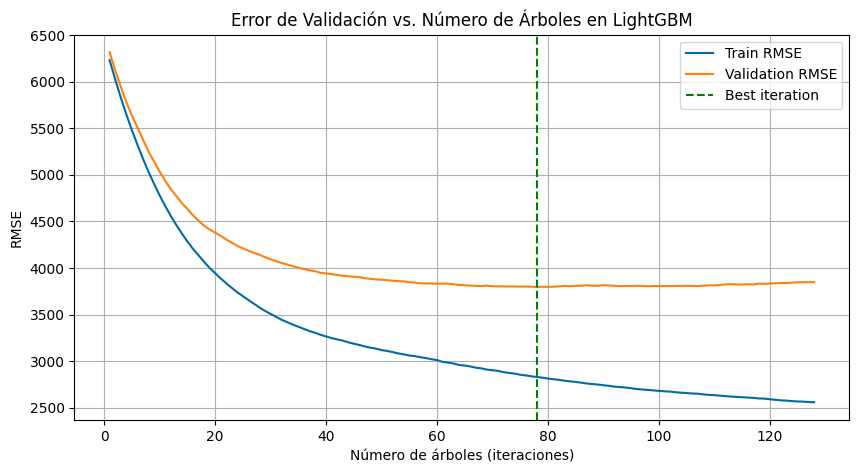

Mejor número de árboles: 78
RMSE de validación en la mejor iteración: 3794.6221


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import lightgbm as lgb


reg_lightgbm = lgb.LGBMRegressor(n_estimators=1000,early_stopping_round=50,learning_rate=0.05)

reg_lightgbm.fit(X_train, y_train,eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_metric='rmse')

results = reg_lightgbm.evals_result_
train_rmse = results['training']['rmse']
valid_rmse = results['valid_1']['rmse']
iterations = np.arange(1, len(train_rmse) + 1)

plt.figure(figsize=(10, 5))
plt.plot(iterations, train_rmse, label='Train RMSE')
plt.plot(iterations, valid_rmse, label='Validation RMSE')
plt.axvline(reg_lightgbm.best_iteration_, color='green', linestyle='--', label='Best iteration')
plt.xlabel('Número de árboles (iteraciones)')
plt.ylabel('RMSE')
plt.title('Error de Validación vs. Número de Árboles en LightGBM')
plt.legend()
plt.grid(True)
plt.show()

print(f"Mejor número de árboles: {reg_lightgbm.best_iteration_}")
print(f"RMSE de validación en la mejor iteración: {valid_rmse[reg_lightgbm.best_iteration_-1]:.4f}")



Con esta data se podria ajustar el learning_rate para balancear velocidad de aprendizaje vs control del sobreajuste, reducir n_estimators para eficiencia y probar max_depth o feature_fraction para afinar la capacidad de generalizacion del modelo.

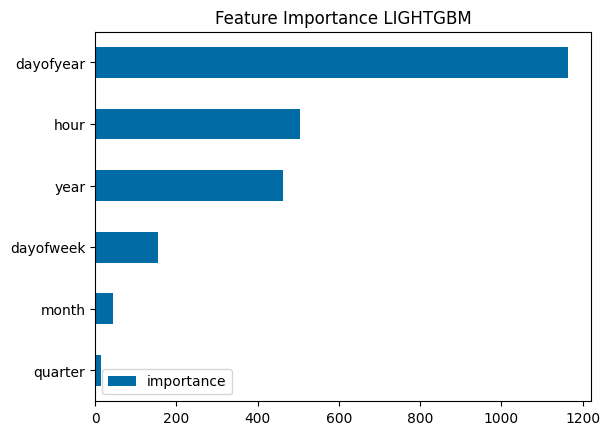

In [ ]:
fi = pd.DataFrame(data=reg_lightgbm.feature_importances_,
             index=reg_lightgbm.feature_names_in_,
             columns=['importance'])
fi.sort_values('importance').plot(kind='barh', title='Feature Importance LIGHTGBM')
plt.show()

Vemos los features mas importantes, ¿ que podriamos hacer ?

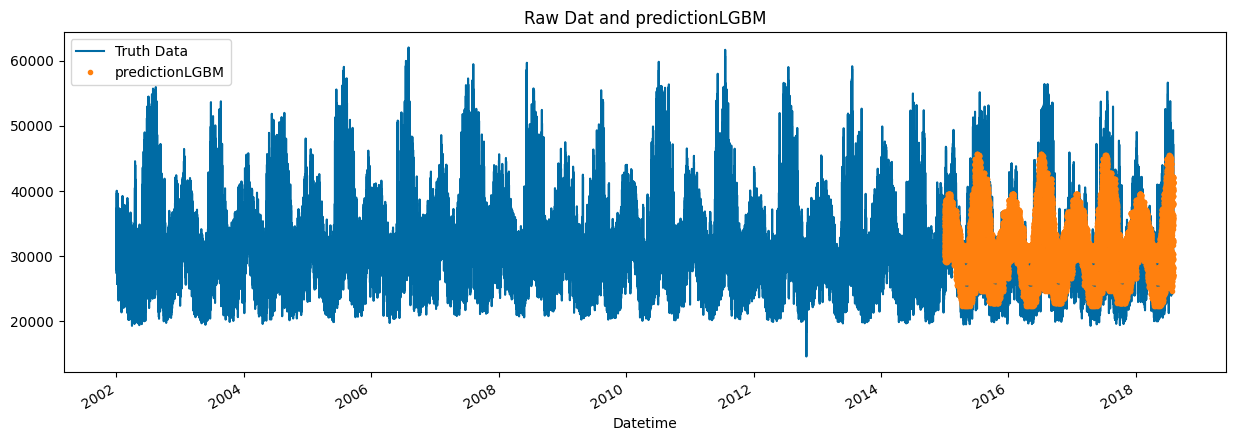

In [ ]:
test['predictionLGBM'] = reg_lightgbm.predict(X_test)
df = df.merge(test[['predictionLGBM']], how='left', left_index=True, right_index=True)
ax = df[['PJME_MW']].plot(figsize=(15, 5))
df['predictionLGBM'].plot(ax=ax, style='.')
plt.legend(['Truth Data', 'predictionLGBM'])
ax.set_title('Raw Dat and predictionLGBM')
plt.show()

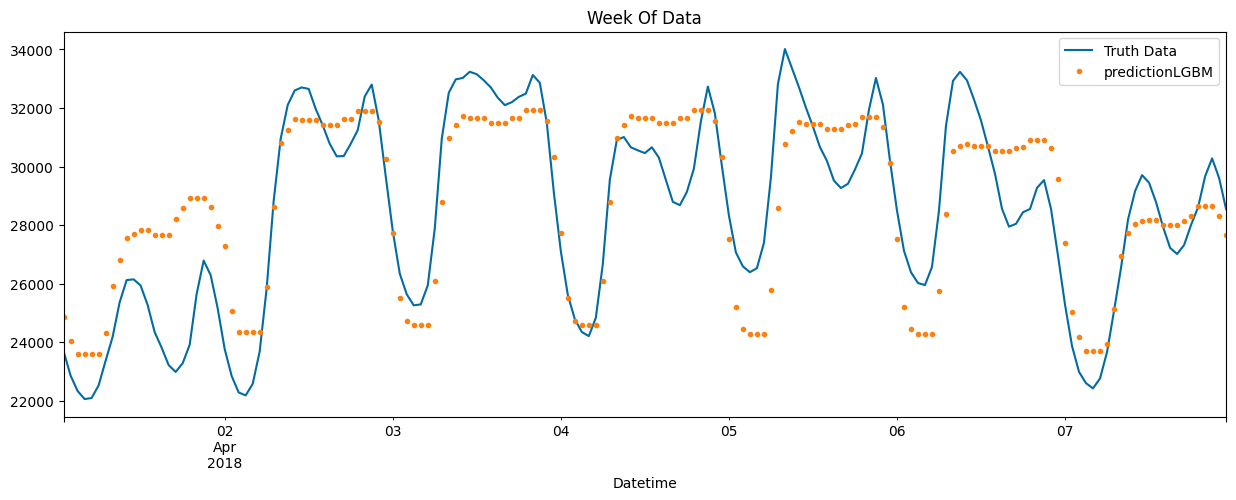

In [ ]:
ax = df.loc[(df.index > '04-01-2018') & (df.index < '04-08-2018')]['PJME_MW'] \
    .plot(figsize=(15, 5), title='Week Of Data')
df.loc[(df.index > '04-01-2018') & (df.index < '04-08-2018')]['predictionLGBM'] \
    .plot(style='.')
plt.legend(['Truth Data','predictionLGBM'])
plt.show()

In [ ]:
test['predictionLGBM'] = reg_lightgbm.predict(X_test)
df = df.merge(test[['predictionLGBM']], how='left', left_index=True, right_index=True)

In [ ]:
test['error_LGBM'] = np.abs(test[TARGET]- test['predictionLGBM'])

In [ ]:
# mejores predicciones
test.groupby('date')['error_LGBM'].mean().sort_values(ascending=True).head(10)

,error_LGBM
date,
2015-03-04,452.172439
2016-01-12,497.639863
2016-12-29,514.509278
2018-05-16,523.196720
2016-12-12,527.535577
2015-07-13,535.363119
2017-05-02,555.252920
2017-04-01,573.850773
2016-10-27,588.243639


In [ ]:
# Peores predicciones
test.groupby('date')['error_LGBM'].mean().sort_values(ascending=False).head(10)

,error_LGBM
date,
2016-08-13,13486.003122
2016-08-14,13281.415097
2016-09-10,12085.382493
2016-08-12,11213.100472
2016-09-09,11127.931902
2018-01-06,10959.034207
2015-02-20,10561.658237
2018-01-07,10232.570995
2016-07-23,10194.558820


Vemos las mejores y peores predicciones, ¿ se puede hacer algun analisis ?

Metricas Globales

In [ ]:
score = np.sqrt(mean_squared_error(test['PJME_MW'], test['predictionLGBM']))
print(f'RMSE en conjunto de Test Modelo LGBM: {score:0.2f}')

RMSE en conjunto de Test Modelo LGBM: 3794.62


In [ ]:
score = np.sqrt(mean_squared_error(test['PJME_MW'], test['prediction_XGB']))
print(f'RMSE en conjunto de Test. Modelo XGBoost: {score:0.2f}')

RMSE en conjunto de Test. Modelo XGBoost: 3745.47


OPTIMIZO LOS HIPERPARAMETROS

1 TECNICAS BAYESIANAS

Al momento estos son las metricas encontradas. ¿ se pueden mejorar ? - Probamos con LightGBM

Optuna ( optimización automatizado de hiperparámetros)

https://optuna.readthedocs.io/en/stable/

In [ ]:
! pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 22.8 MB/s eta 0:00:00


In [ ]:
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import make_scorer, mean_squared_error
import numpy as np

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better=False)

model = lgb.LGBMRegressor(objective='regression', verbose=-1)

param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'num_leaves': [31, 50, 100],
    'min_child_samples': [20, 50],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9],
}

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=rmse_scorer,
    cv=tscv,
    verbose=3,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(" Mejor combinación de hiperparámetros encontrada:")
print(grid_search.best_params_)

print(f" Mejor RMSE en validación: {abs(grid_search.best_score_):.4f}")



Fitting 5 folds for each of 216 candidates, totalling 1080 fits
 Mejor combinación de hiperparámetros encontrada:
{'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_samples': 20, 'num_leaves': 31, 'subsample': 0.7}
 Mejor RMSE en validación: 3436.1228


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[70]	valid_0's rmse: 3676.39	valid_0's l2: 1.35158e+07
RMSE en test: 3676.3850


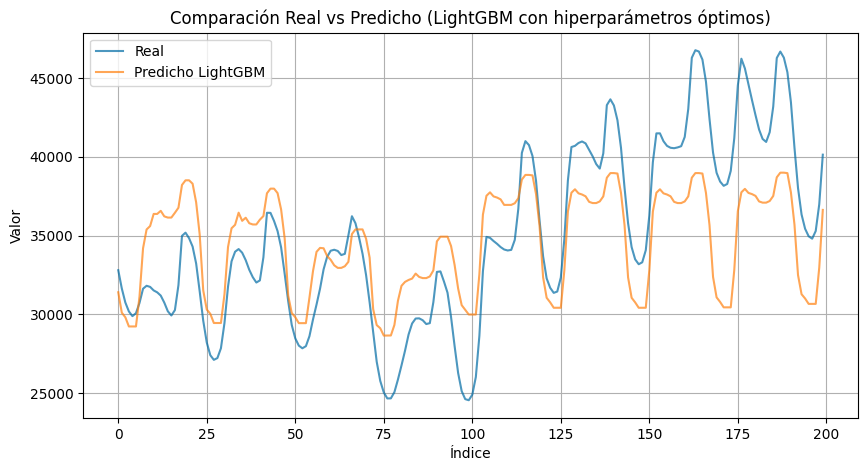

In [ ]:
import lightgbm as lgb
from sklearn.metrics import mean_squared_error
import numpy as np

# Hiperparametros de Optuna
best_params = {
    'learning_rate': 0.08537669885680496,
    'max_depth': 4,
    'num_leaves': 144,
    'min_child_samples': 57,
    'subsample': 0.6295322967023701,
    'colsample_bytree': 0.6084128502035824,
    'reg_alpha': 0.09277159545496648,
    'reg_lambda': 0.028516774337990002,
    'n_estimators': 2000,
}


reg_lightgbm_2 = lgb.LGBMRegressor(**best_params)


reg_lightgbm_2.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    eval_metric='rmse',
    callbacks=[lgb.early_stopping(50)],
)


y_pred = reg_lightgbm_2.predict(X_test)


rmse = mean_squared_error(y_test, y_pred) ** 0.5
print(f"RMSE en test: {rmse:.4f}")


import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(y_test[:200].reset_index(drop=True), label='Real', alpha=0.7)
plt.plot(y_pred[:200], label='Predicho LightGBM', alpha=0.7)
plt.title('Comparación Real vs Predicho (LightGBM con hiperparámetros óptimos)')
plt.xlabel('Índice')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.show()


GRID SEARCH

In [ ]:
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import make_scorer, mean_squared_error
import numpy as np

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better=False)

model = lgb.LGBMRegressor(objective='regression', verbose=-1)

param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'num_leaves': [31, 50, 100],
    'min_child_samples': [20, 50],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9],
}

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=rmse_scorer,
    cv=tscv,
    verbose=3,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(" Mejor combinación de hiperparámetros encontrada:")
print(grid_search.best_params_)

print(f" Mejor RMSE en validación: {abs(grid_search.best_score_):.4f}")


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
 Mejor combinación de hiperparámetros encontrada:
{'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 4, 'min_child_samples': 20, 'num_leaves': 31, 'subsample': 0.7}
 Mejor RMSE en validación: 3436.1228


params = {
    'colsample_bytree': 0.7,
    'learning_rate': 0.05,
    'max_depth': 4,
    'min_child_samples': 20,
    'num_leaves': 31,
    'subsample': 0.7,
    'n_estimators': 2000,  # largo para early stopping
}

Tambien probamos con "Cross Validation"

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

tss = TimeSeriesSplit(n_splits=5, test_size=24*365*1, gap=24)  # predecir 1 año  , gap entre entrenamiento y validacion de 24 horas
df_copy = df.copy()
df_copy = df_copy.sort_index()

In [ ]:
tss

TimeSeriesSplit(gap=24, max_train_size=None, n_splits=5, test_size=8760)

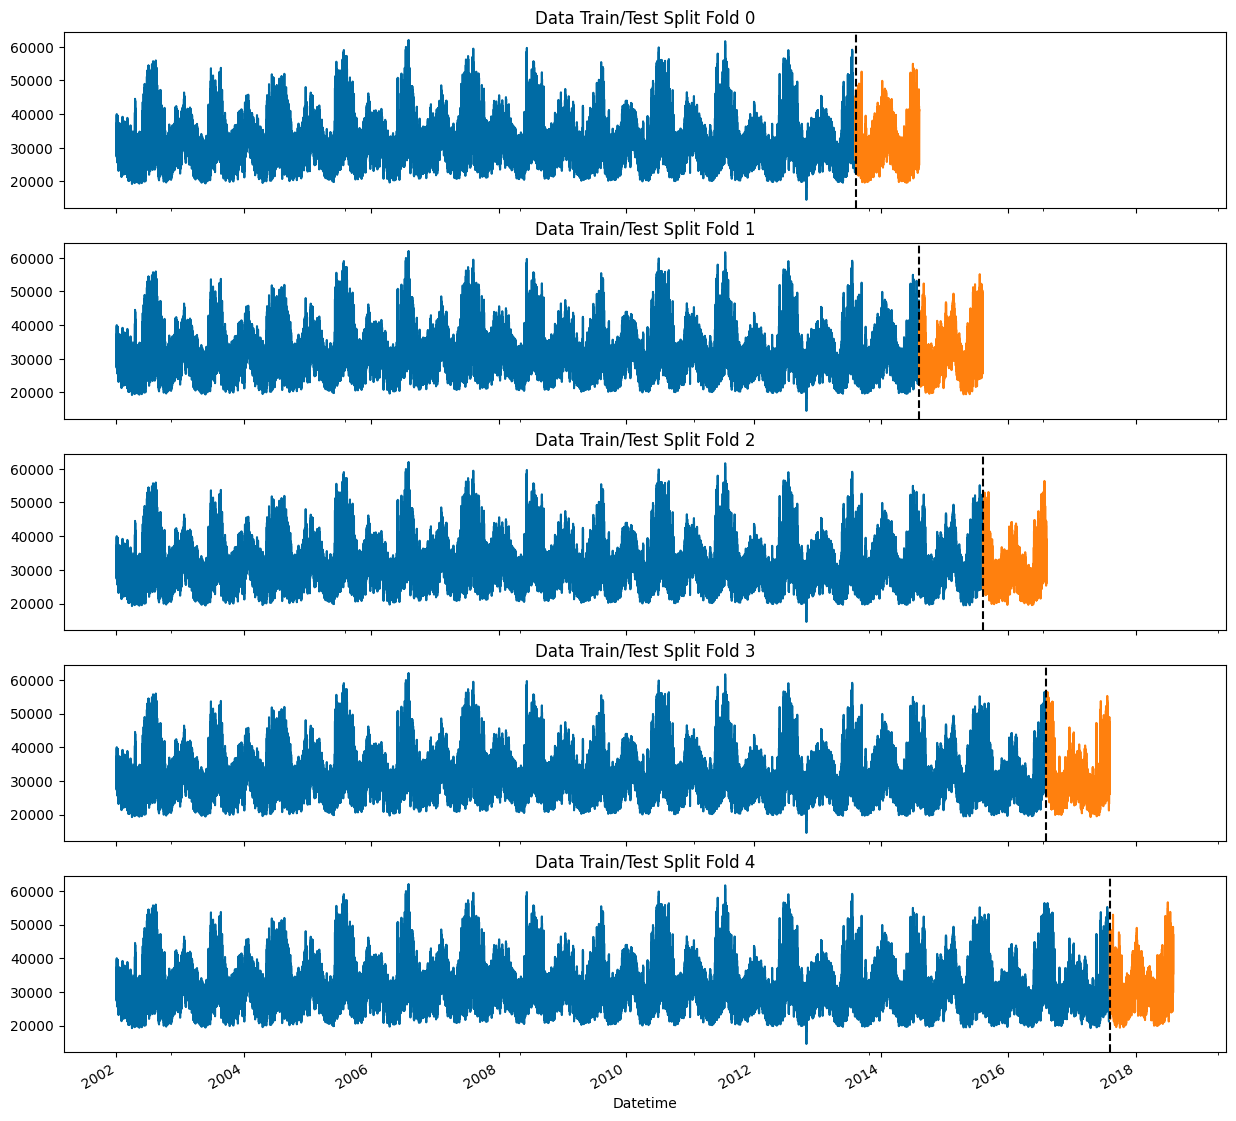

In [ ]:
fig, axs = plt.subplots(5, 1, figsize=(15, 15), sharex=True)

fold = 0
for train_idx, val_idx in tss.split(df_copy):
    train = df_copy.iloc[train_idx]
    test = df_copy.iloc[val_idx]
    train['PJME_MW'].plot(ax=axs[fold],
                          label='Training Set',
                          title=f'Data Train/Test Split Fold {fold}')
    test['PJME_MW'].plot(ax=axs[fold],
                         label='Test Set')
    axs[fold].axvline(test.index.min(), color='black', ls='--')
    fold += 1
plt.show()

Agregar Lags como Features

In [ ]:
def add_lags(df):
    target_map = df['PJME_MW'].to_dict()
    df['lag1'] = (df.index - pd.Timedelta('364 days')).map(target_map)
    df['lag2'] = (df.index - pd.Timedelta('728 days')).map(target_map)
    df['lag3'] = (df.index - pd.Timedelta('1092 days')).map(target_map)
    return df

In [ ]:
df = add_lags(df)

Train Using Cross Validation¶


In [ ]:
tss = TimeSeriesSplit(n_splits=5, test_size=24*365*1, gap=24)
df = df.sort_index()


fold = 0
preds = []
scores = []
for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]

    train = create_features(train)
    test = create_features(test)

    FEATURES = ['dayofyear', 'hour', 'dayofweek', 'quarter', 'month','year',
                'lag1','lag2','lag3']
    TARGET = 'PJME_MW'

    X_train = train[FEATURES]
    y_train = train[TARGET]

    X_test = test[FEATURES]
    y_test = test[TARGET]

    reg = xgb.XGBRegressor(base_score=0.5, booster='gbtree',
                           n_estimators=1000,
                           early_stopping_rounds=50,
                           objective='reg:linear',
                           max_depth=3,
                           learning_rate=0.01)
    reg.fit(X_train, y_train,
            eval_set=[(X_train, y_train), (X_test, y_test)],
            verbose=100)

    y_pred = reg.predict(X_test)
    preds.append(y_pred)
    score = np.sqrt(mean_squared_error(y_test, y_pred))
    scores.append(score)

[0]	validation_0-rmse:32728.69634	validation_1-rmse:32006.86635


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:43:41] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)


[100]	validation_0-rmse:12533.13636	validation_1-rmse:11960.34032
[200]	validation_0-rmse:5751.00972	validation_1-rmse:5366.77615
[300]	validation_0-rmse:3876.13308	validation_1-rmse:3841.41674
[400]	validation_0-rmse:3444.25284	validation_1-rmse:3669.28162
[488]	validation_0-rmse:3332.42101	validation_1-rmse:3667.97908
[0]	validation_0-rmse:32671.86342	validation_1-rmse:32155.89701


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:43:49] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)


[100]	validation_0-rmse:12514.10566	validation_1-rmse:12246.33582
[200]	validation_0-rmse:5756.43623	validation_1-rmse:5690.07179
[300]	validation_0-rmse:3906.79900	validation_1-rmse:3953.46093
[400]	validation_0-rmse:3481.58202	validation_1-rmse:3603.25338
[500]	validation_0-rmse:3357.58004	validation_1-rmse:3524.50447
[600]	validation_0-rmse:3301.70502	validation_1-rmse:3489.14496
[700]	validation_0-rmse:3262.05229	validation_1-rmse:3465.35601
[800]	validation_0-rmse:3225.04460	validation_1-rmse:3441.64780
[900]	validation_0-rmse:3198.28552	validation_1-rmse:3432.56017
[999]	validation_0-rmse:3169.14844	validation_1-rmse:3421.83469
[0]	validation_0-rmse:32634.36881	validation_1-rmse:31003.83739


...

[100]	validation_0-rmse:12500.74215	validation_1-rmse:11094.03695
[200]	validation_0-rmse:5752.07246	validation_1-rmse:4776.86259
[300]	validation_0-rmse:3917.70094	validation_1-rmse:3524.49482
[400]	validation_0-rmse:3495.37256	validation_1-rmse:3479.88472
[408]	validation_0-rmse:3481.22039	validation_1-rmse:3487.04605
[0]	validation_0-rmse:32526.02337	validation_1-rmse:31438.48444


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:44:09] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)


[100]	validation_0-rmse:12461.42806	validation_1-rmse:12008.70597
[200]	validation_0-rmse:5737.37378	validation_1-rmse:5799.81439
[300]	validation_0-rmse:3916.50594	validation_1-rmse:4391.07552
[400]	validation_0-rmse:3498.80019	validation_1-rmse:4176.47678
[500]	validation_0-rmse:3383.25907	validation_1-rmse:4118.91932
[600]	validation_0-rmse:3324.32132	validation_1-rmse:4108.38582
[700]	validation_0-rmse:3281.79000	validation_1-rmse:4091.09930
[800]	validation_0-rmse:3249.30039	validation_1-rmse:4083.92723
[900]	validation_0-rmse:3222.83815	validation_1-rmse:4080.86294
[999]	validation_0-rmse:3199.28299	validation_1-rmse:4066.01906
[0]	validation_0-rmse:32457.31197	validation_1-rmse:31417.91480


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:44:25] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)


[100]	validation_0-rmse:12444.15715	validation_1-rmse:11934.58482
[200]	validation_0-rmse:5751.53604	validation_1-rmse:5599.28951
[300]	validation_0-rmse:3950.99108	validation_1-rmse:4146.82377
[400]	validation_0-rmse:3542.70123	validation_1-rmse:3999.80441
[461]	validation_0-rmse:3461.63030	validation_1-rmse:4007.16986


In [ ]:
print(f'Score across folds {np.mean(scores):0.4f}')
print(f'Fold scores:{scores}')

Score across folds 3720.8721
Fold scores:[np.float64(3662.6390744936843), np.float64(3420.8236790646915), np.float64(3456.9429978017), np.float64(4066.019060938989), np.float64(3997.9357144332985)]


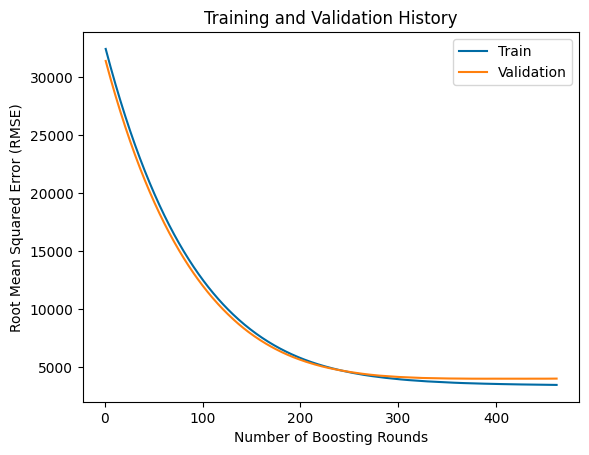

In [ ]:
results = reg.evals_result()
train_error = results['validation_0']['rmse']
val_error = results['validation_1']['rmse']

epoch = range(1, len(train_error) + 1)

plt.plot(epoch, train_error, label='Train')
plt.plot(epoch, val_error, label='Validation')
plt.xlabel('Number of Boosting Rounds')
plt.ylabel('Root Mean Squared Error (RMSE)')
plt.title('Training and Validation History')
plt.legend()
plt.show()

4. Predecir el futuro Reentrenamiento en todos los datos
Para predecir el futuro necesitamos un marco de datos vacío para rangos de fechas futuros.
Ejecute esas fechas a través de nuestro código de creación de funciones + creación de retrasos

In [ ]:
# Retrain on all data
df = create_features(df)

FEATURES = ['dayofyear', 'hour', 'dayofweek', 'quarter', 'month', 'year',
            'lag1','lag2','lag3']
TARGET = 'PJME_MW'

X_all = df[FEATURES]
y_all = df[TARGET]

reg = xgb.XGBRegressor(base_score=0.5,
                       booster='gbtree',
                       n_estimators=500,
                       objective='reg:linear',
                       max_depth=3,
                       learning_rate=0.01)
reg.fit(X_all, y_all,
        eval_set=[(X_all, y_all)],
        verbose=100)

[0]	validation_0-rmse:32396.83896


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:44:32] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)


[100]	validation_0-rmse:12424.54947
[200]	validation_0-rmse:5751.72436
[300]	validation_0-rmse:3970.24008
[400]	validation_0-rmse:3569.35550
[499]	validation_0-rmse:3455.41959


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.01, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=3, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=500, n_jobs=None,
             num_parallel_tree=None, objective='reg:linear', ...)

In [ ]:
df.index.max()

Timestamp('2018-08-03 00:00:00')

In [ ]:
# Create future dataframe
future = pd.date_range('2018-08-03','2019-08-01', freq='1h')
future_df = pd.DataFrame(index=future)
future_df['isFuture'] = True
df['isFuture'] = False
df_and_future = pd.concat([df, future_df])
df_and_future = create_features(df_and_future)
df_and_future = add_lags(df_and_future)

In [ ]:
future_w_features = df_and_future.query('isFuture').copy()


In [ ]:
future_w_features.head()

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear,prediction_XGB_x,prediction_XGB_y,predictionLGBM_x,predictionLGBM_y,lag1,lag2,lag3,isFuture
2018-08-03 00:00:00,NaN,0,4,3,8,2018,215,3,31,NaN,NaN,NaN,NaN,33539.0,32094.0,31695.0,True
2018-08-03 01:00:00,NaN,1,4,3,8,2018,215,3,31,NaN,NaN,NaN,NaN,30781.0,29503.0,29128.0,True
2018-08-03 02:00:00,NaN,2,4,3,8,2018,215,3,31,NaN,NaN,NaN,NaN,29015.0,27712.0,27373.0,True
2018-08-03 03:00:00,NaN,3,4,3,8,2018,215,3,31,NaN,NaN,NaN,NaN,27884.0,26535.0,26233.0,True
2018-08-03 04:00:00,NaN,4,4,3,8,2018,215,3,31,NaN,NaN,NaN,NaN,27223.0,25870.0,25643.0,True


Predict the future¶


In [ ]:
future_w_features['pred'] = reg.predict(future_w_features[FEATURES])


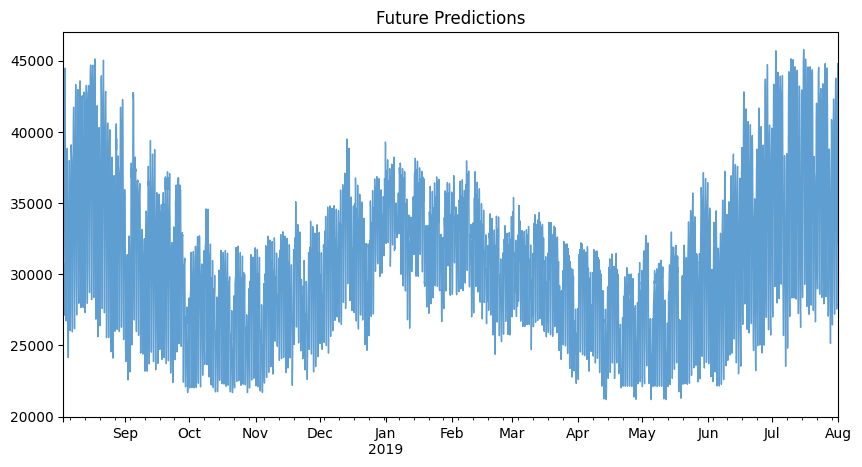

In [ ]:
future_w_features['pred'].plot(figsize=(10, 5),
                               color=color_pal[4],
                               ms=1,
                               lw=1,
                               title='Future Predictions')
plt.show()

Guardar el modelo

In [ ]:
reg.save_model('model.json')

<Axes: title={'center': 'Future Predictions'}>

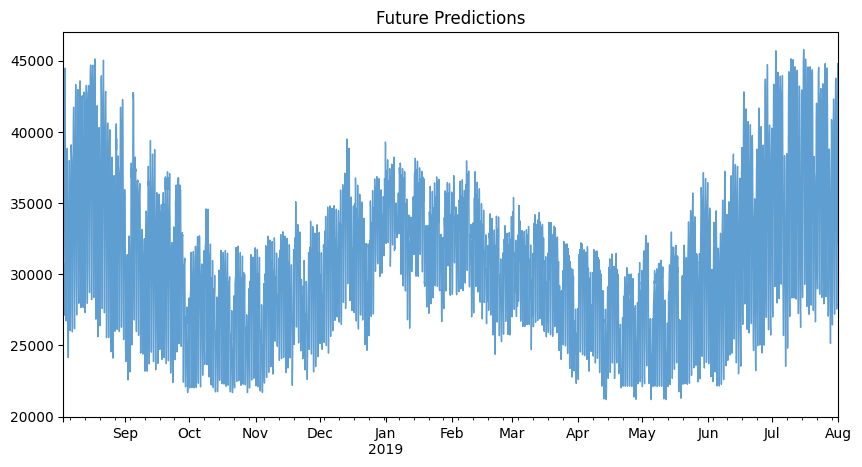

In [ ]:
reg_new = xgb.XGBRegressor()
reg_new.load_model('model.json')
future_w_features['pred'] = reg_new.predict(future_w_features[FEATURES])
future_w_features['pred'].plot(figsize=(10, 5),
                               color=color_pal[4],
                               ms=1, lw=1,
                               title='Future Predictions')

ACTIVIDAD AL FINALIZAR !!

Modificar el modelo para mejorar el desempeño.

Pueden:

-agregar o quitar lags
- modificar el learning_rate
- cambiar max_depth o num_leaves
- agregar una feature temporal nueva.
- feature engineering
-o cualquier otra idea para aprender.

Juegen un poco con el codigo y preparense para exponer los resultados!




In [ ]:
# Comiencen con las pruebas!



